# EDA Project: Smart TV


## Exploratory Data Analysis on Smart TV


**Business Problem Statement**

Smart TV buyers are confused due to technical jargon (OLED, QLED, 4K, HDR) and unclear value-for-money differences across brands. The goal of this

project is to analyze Smart TV data (scraped from Poorvika) using Exploratory Data Analysis (EDA) to uncover pricing patterns and determine how

specific features impact the market price.

**Problem Definition**
A customer ananya is shopping for a 55-inch 4K TV. she sees a Smart Tv for ₹35,000 and for ₹65,000. Both have "4K UHD" on the box. Ananya wants to know
if she is paying ₹30,000 for better picture quality or just for the logo.        

**Business Questions**

*The Resolution Premium-> Is paying more for 4K or 8K actually worth the investment for the average viewer?

*Feature Impact-> Do higher Screen Size and Resolution significantly impact the final price?

*Satisfaction vs Cost-> do higher prices, or do budget TVs offer better value?

*Price Drivers-> Which technical features (Display type, Brand, Resolution) genuinely increase TV prices?

*Value for Money-> Which Smart TVs provide the best "Price-per-Inch" ratio for the consumer?

**Project Objectives**

Identify Price Drivers-> Quantify the price increase associated with moving from HD to 4K and 8K resolutions.

Detect Cost Inflators-> Isolate instances where brand name or minor features cause "unnecessary" price hikes without significant hardware upgrades.

Outlier Analysis-> Analyze the extreme price points of 8K and premium 4K TVs (as seen in the initial boxplots) to see if they follow market trends.

Recommend Optimal Combinations-> Identify the "sweet spot" for screen size and resolution that offers the best performance for ananya's budget.

Data-Driven Decisions-> Help buyers move away from brand bias and make purchases based on hardware value.

In [109]:
import requests as re
from bs4 import  BeautifulSoup
import regex as rx
import pandas as pd
import numpy as np

In [110]:
url="https://www.poorvika.com/smart+tv/s?q=smart+tv"
url

'https://www.poorvika.com/smart+tv/s?q=smart+tv'

In [111]:
page=re.get(url)
page

<Response [200]>

In [112]:
soup=BeautifulSoup(page.text)
soup

<!DOCTYPE html>
<html><head><meta charset="utf-8"/><title> Buy smart tv Online at Best Price in India | Poorvika</title><link href="https://www.poorvika.com/smart tv/s" media="all" rel="canonical"/><meta content=" Buy smart tv Online at Best Price in India | Poorvika" name="title"/><meta content="width=device-width, initial-scale=1, maximum-scale=1" name="viewport"/><meta content="smart tv,search,poorvika, Poorvika, Electronics, mobiles" name="keywords"/><meta content="Get the latest smart tv online at the best price. Explore wide range and exciting deals only at Poorvika." name="description"/><meta content="https://www.poorvika.com/smart tv/s" property="og:url"/><meta content="e-commercing" property="og:type"/><meta content=" Buy smart tv Online at Best Price in India | Poorvika" property="og:title"/><meta content="Get the latest smart tv online at the best price. Explore wide range and exciting deals only at Poorvika." property="og:description"/><meta content="https://cdn.example.com

In [113]:
feature=soup.find_all('div',class_="product-cardlist_card__description__eduH5")
feature

[<div class="product-cardlist_card__description__eduH5"><a href="/xiaomi-led-smart-tv-a-series-2025-hd-32-inch/p" target="_blank"><b>Xiaomi LED Smart TV A Series 2025 HD ( 32 inch )</b><small class="product-cardlist_product_variant__qTEsA visible">( 32 inch )</small><div class="product-cardlist_storage__SvjkE"></div><div class="product-cardlist_price__1aKwZ"><span class="whitespace-nowrap">₹ 13,999</span><span style="flex:1"></span></div><div class="product-cardlist_savings__fk1lf"><s>₹ 24,999</s><b>44<!-- -->% OFF</b></div></a><div class="product-cardlist_product-tool-tip__lPD6f">Xiaomi LED Smart TV A Series 2025 HD ( 32 inch )</div></div>,
 <div class="product-cardlist_card__description__eduH5"><a href="/xiaomi-led-smart-tv-a-series-2025-full-hd-43-inch/p" target="_blank"><b>Xiaomi LED Smart TV A Series 2025 Full HD ( 43 inch )</b><small class="product-cardlist_product_variant__qTEsA visible">( 43 inch )</small><div class="product-cardlist_storage__SvjkE"></div><div class="product-ca

In [114]:
for i in feature:
    print(i.text)

Xiaomi LED Smart TV A Series 2025 HD ( 32 inch )( 32 inch )₹ 13,999₹ 24,99944% OFFXiaomi LED Smart TV A Series 2025 HD ( 32 inch )
Xiaomi LED Smart TV A Series 2025 Full HD ( 43 inch )( 43 inch )₹ 20,999₹ 34,99940% OFFXiaomi LED Smart TV A Series 2025 Full HD ( 43 inch )
Xiaomi X Pro QLED Series 2025 Smart TV 4K Ultra HD ( 65 inch )( 65 inch )₹ 57,999₹ 99,99942% OFFXiaomi X Pro QLED Series 2025 Smart TV 4K Ultra HD ( 65 inch )
Xiaomi X Pro QLED Series 2025 Smart TV 4K Ultra HD ( 55 inch )( 55 inch )₹ 39,999₹ 69,99943% OFFXiaomi X Pro QLED Series 2025 Smart TV 4K Ultra HD ( 55 inch )
Xiaomi X Pro QLED Series 2025 Smart TV 4K Ultra HD ( 43 inch )( 43 inch )₹ 28,999₹ 49,99942% OFFXiaomi X Pro QLED Series 2025 Smart TV 4K Ultra HD ( 43 inch )
Xiaomi LED Smart TV A Series 2024 ( 43 inch )( 43 inch )₹ 20,280₹ 35,99944% OFFXiaomi LED Smart TV A Series 2024 ( 43 inch )
Xiaomi X Pro QLED Smart TV 4K Ultra HD ( 55 inch )( 55 inch )₹ 38,718₹ 70,99945% OFFXiaomi X Pro QLED Smart TV 4K Ultra HD ( 5

In [115]:
screen_size=[]
for i in feature:
    r=i.text
    rr=rx.findall(r'(\d+\s*inch)',r)
    if len(rr)>0:
      screen_size.append(rr[0])
    else:
      screen_size.append(np.nan)
screen_size

['32 inch',
 '43 inch',
 '65 inch',
 '55 inch',
 '43 inch',
 '43 inch',
 '55 inch',
 '65 inch',
 '50 inch',
 '55 inch',
 '43 inch',
 '32 inch',
 '43 inch',
 '32 inch',
 nan,
 '85 inch',
 '55 inch',
 '75 inch',
 '98 inch',
 '43 inch',
 '75 inch',
 '85 inch',
 '75 inch',
 '43 inch',
 '55 inch',
 '75 inch',
 '85 inch',
 '65 inch',
 '75 inch',
 '50 inch',
 nan,
 '43 inch',
 '65 inch',
 '65 inch',
 '75 inch',
 '75 inch',
 '65 inch',
 '65 inch',
 '75 inch',
 '85 inch']

In [116]:
len(screen_size)

40

In [117]:
model1=[]
for i in feature:
  r=i.text
  rr=rx.findall(r'([A-Za-z0-9\s]+Series\s\d{4}|[A-Z]{1,3}\d+[A-Z0-9]+|\d+[A-Z])',r)[0]
  print(rr)

Xiaomi LED Smart TV A Series 2025
Xiaomi LED Smart TV A Series 2025
Xiaomi X Pro QLED Series 2025
Xiaomi X Pro QLED Series 2025
Xiaomi X Pro QLED Series 2025
Xiaomi LED Smart TV A Series 2024
4K
4K
Xiaomi LED Smart TV X Series 2024
Xiaomi LED Smart TV X Series 2024
Xiaomi LED Smart TV X Series 2024
Xiaomi HD Ready LED Smart TV A Series 2024


IndexError: list index out of range

In [ ]:
off=soup.find_all("div",class_="product-cardlist_savings__fk1lf")
off

In [ ]:
off=soup.find_all("div",class_="product-cardlist_savings__fk1lf")
offff = []
for i in off:
    a=(i.text)
    b= rx.findall(r'(\d{2})%\sOFF',a)
    if len(b)>0:
        offff.append(b[0])
    else:
        offff.append(np.nan)

In [ ]:
offff

In [ ]:
org_price=soup.find_all("div",class_="product-cardlist_savings__fk1lf")
org_price = []
for i in off:
    a=(i.text)
    b= rx.findall(r'\d+\,\d{3}|\d+\,\d+\,\d{3}',a)
    if len(b)>0:
        org_price.append(b[0])
    else:
        org_price.append(np.nan)
org_price

In [118]:
p=soup.find_all("span",class_="whitespace-nowrap")
p

[<span class="whitespace-nowrap">₹ 13,999</span>,
 <span class="whitespace-nowrap">₹ 20,999</span>,
 <span class="whitespace-nowrap">₹ 57,999</span>,
 <span class="whitespace-nowrap">₹ 39,999</span>,
 <span class="whitespace-nowrap">₹ 28,999</span>,
 <span class="whitespace-nowrap">₹ 20,280</span>,
 <span class="whitespace-nowrap">₹ 38,718</span>,
 <span class="whitespace-nowrap">₹ 58,077</span>,
 <span class="whitespace-nowrap">₹ 27,655</span>,
 <span class="whitespace-nowrap">₹ 34,108</span>,
 <span class="whitespace-nowrap">₹ 22,124</span>,
 <span class="whitespace-nowrap">₹ 11,999</span>,
 <span class="whitespace-nowrap">₹ 20,280</span>,
 <span class="whitespace-nowrap">₹ 11,999</span>,
 <span class="whitespace-nowrap">₹ 26,733</span>,
 <span class="whitespace-nowrap">₹ 3,10,990</span>,
 <span class="whitespace-nowrap">₹ 1,01,900</span>,
 <span class="whitespace-nowrap">₹ 4,44,900</span>,
 <span class="whitespace-nowrap">₹ 5,62,900</span>,
 <span class="whitespace-nowrap">₹ 29,990<

In [119]:
price=soup.find_all("span",class_="whitespace-nowrap")
price

[<span class="whitespace-nowrap">₹ 13,999</span>,
 <span class="whitespace-nowrap">₹ 20,999</span>,
 <span class="whitespace-nowrap">₹ 57,999</span>,
 <span class="whitespace-nowrap">₹ 39,999</span>,
 <span class="whitespace-nowrap">₹ 28,999</span>,
 <span class="whitespace-nowrap">₹ 20,280</span>,
 <span class="whitespace-nowrap">₹ 38,718</span>,
 <span class="whitespace-nowrap">₹ 58,077</span>,
 <span class="whitespace-nowrap">₹ 27,655</span>,
 <span class="whitespace-nowrap">₹ 34,108</span>,
 <span class="whitespace-nowrap">₹ 22,124</span>,
 <span class="whitespace-nowrap">₹ 11,999</span>,
 <span class="whitespace-nowrap">₹ 20,280</span>,
 <span class="whitespace-nowrap">₹ 11,999</span>,
 <span class="whitespace-nowrap">₹ 26,733</span>,
 <span class="whitespace-nowrap">₹ 3,10,990</span>,
 <span class="whitespace-nowrap">₹ 1,01,900</span>,
 <span class="whitespace-nowrap">₹ 4,44,900</span>,
 <span class="whitespace-nowrap">₹ 5,62,900</span>,
 <span class="whitespace-nowrap">₹ 29,990<

In [120]:
len(price)

40

In [121]:
discount_p=soup.find_all('div',class_="product-cardlist_savings__fk1lf")
discount_p

[<div class="product-cardlist_savings__fk1lf"><s>₹ 24,999</s><b>44<!-- -->% OFF</b></div>,
 <div class="product-cardlist_savings__fk1lf"><s>₹ 34,999</s><b>40<!-- -->% OFF</b></div>,
 <div class="product-cardlist_savings__fk1lf"><s>₹ 99,999</s><b>42<!-- -->% OFF</b></div>,
 <div class="product-cardlist_savings__fk1lf"><s>₹ 69,999</s><b>43<!-- -->% OFF</b></div>,
 <div class="product-cardlist_savings__fk1lf"><s>₹ 49,999</s><b>42<!-- -->% OFF</b></div>,
 <div class="product-cardlist_savings__fk1lf"><s>₹ 35,999</s><b>44<!-- -->% OFF</b></div>,
 <div class="product-cardlist_savings__fk1lf"><s>₹ 70,999</s><b>45<!-- -->% OFF</b></div>,
 <div class="product-cardlist_savings__fk1lf"><s>₹ 99,999</s><b>42<!-- -->% OFF</b></div>,
 <div class="product-cardlist_savings__fk1lf"><s>₹ 49,999</s><b>45<!-- -->% OFF</b></div>,
 <div class="product-cardlist_savings__fk1lf"><s>₹ 55,999</s><b>39<!-- -->% OFF</b></div>,
 <div class="product-cardlist_savings__fk1lf"><s>₹ 42,999</s><b>49<!-- -->% OFF</b></div>,

In [122]:
brand1=soup.find_all('div',class_="product-cardlist_product-tool-tip__lPD6f")
brand1

[<div class="product-cardlist_product-tool-tip__lPD6f">Xiaomi LED Smart TV A Series 2025 HD ( 32 inch )</div>,
 <div class="product-cardlist_product-tool-tip__lPD6f">Xiaomi LED Smart TV A Series 2025 Full HD ( 43 inch )</div>,
 <div class="product-cardlist_product-tool-tip__lPD6f">Xiaomi X Pro QLED Series 2025 Smart TV 4K Ultra HD ( 65 inch )</div>,
 <div class="product-cardlist_product-tool-tip__lPD6f">Xiaomi X Pro QLED Series 2025 Smart TV 4K Ultra HD ( 55 inch )</div>,
 <div class="product-cardlist_product-tool-tip__lPD6f">Xiaomi X Pro QLED Series 2025 Smart TV 4K Ultra HD ( 43 inch )</div>,
 <div class="product-cardlist_product-tool-tip__lPD6f">Xiaomi LED Smart TV A Series 2024 ( 43 inch )</div>,
 <div class="product-cardlist_product-tool-tip__lPD6f">Xiaomi X Pro QLED Smart TV 4K Ultra HD ( 55 inch )</div>,
 <div class="product-cardlist_product-tool-tip__lPD6f">Xiaomi X Pro QLED Smart TV 4K Ultra HD ( 65 inch )</div>,
 <div class="product-cardlist_product-tool-tip__lPD6f">Xiaomi LE

In [123]:
for i in brand1:
    a=i.text.split()
    print(a)

['Xiaomi', 'LED', 'Smart', 'TV', 'A', 'Series', '2025', 'HD', '(', '32', 'inch', ')']
['Xiaomi', 'LED', 'Smart', 'TV', 'A', 'Series', '2025', 'Full', 'HD', '(', '43', 'inch', ')']
['Xiaomi', 'X', 'Pro', 'QLED', 'Series', '2025', 'Smart', 'TV', '4K', 'Ultra', 'HD', '(', '65', 'inch', ')']
['Xiaomi', 'X', 'Pro', 'QLED', 'Series', '2025', 'Smart', 'TV', '4K', 'Ultra', 'HD', '(', '55', 'inch', ')']
['Xiaomi', 'X', 'Pro', 'QLED', 'Series', '2025', 'Smart', 'TV', '4K', 'Ultra', 'HD', '(', '43', 'inch', ')']
['Xiaomi', 'LED', 'Smart', 'TV', 'A', 'Series', '2024', '(', '43', 'inch', ')']
['Xiaomi', 'X', 'Pro', 'QLED', 'Smart', 'TV', '4K', 'Ultra', 'HD', '(', '55', 'inch', ')']
['Xiaomi', 'X', 'Pro', 'QLED', 'Smart', 'TV', '4K', 'Ultra', 'HD', '(', '65', 'inch', ')']
['Xiaomi', 'LED', 'Smart', 'TV', 'X', 'Series', '2024', '4K', 'Ultra', 'HD', '(', '50', 'inch', ')']
['Xiaomi', 'LED', 'Smart', 'TV', 'X', 'Series', '2024', '4K', 'Ultra', 'HD', '(', '55', 'inch', ')']
['Xiaomi', 'LED', 'Smart', 'T

In [124]:
discounted_prices=[]
for i in feature:
  r=i.text
  p = rx.findall(r'₹\s?([\d,]+)',r)
  discounted_prices.append(p[0])
print(discounted_prices)

['13,999', '20,999', '57,999', '39,999', '28,999', '20,280', '38,718', '58,077', '27,655', '34,108', '22,124', '11,9995', '20,2804', '11,9994', '26,733', '3,10,990', '1,01,900', '4,44,900', '5,62,900', '29,990', '91,990', '7,26,900', '1,97,990', '20,790', '1,63,490', '1,07,990', '2,13,900', '2,09,990', '1,40,900', '49,990', '4,61,900', '41,990', '84,490', '99,990', '1,11,900', '3,50,990', '60,990', '2,47,990', '2,43,990', '3,10,990']


In [125]:
disc_price=[]
for item in discounted_prices:
    if ',' in item:
        parts = item.split(',')
        parts[-1] = parts[-1][:3] 
        cleaned_item = ",".join(parts)
        disc_price.append(cleaned_item)
    else:
        disc_price.append(item)

print(disc_price)

['13,999', '20,999', '57,999', '39,999', '28,999', '20,280', '38,718', '58,077', '27,655', '34,108', '22,124', '11,999', '20,280', '11,999', '26,733', '3,10,990', '1,01,900', '4,44,900', '5,62,900', '29,990', '91,990', '7,26,900', '1,97,990', '20,790', '1,63,490', '1,07,990', '2,13,900', '2,09,990', '1,40,900', '49,990', '4,61,900', '41,990', '84,490', '99,990', '1,11,900', '3,50,990', '60,990', '2,47,990', '2,43,990', '3,10,990']


In [126]:
discounted_prices1=[]
for i in feature:
    r = i.text
    p = rx.findall(r'₹\s?([\d,]+)', r)
    if p:
        price_str = p[0]
        
        # Fix the "4 digits after comma" issue
        if ',' in price_str:
            parts = price_str.split(',')
            # Truncate the extra digit (e.g., '9995' -> '999')
            parts[-1] = parts[-1][:3] 
            # Rejoin with the comma to keep it as a string for now
            price_str = ",".join(parts) 
            
        discounted_prices1.append(price_str)

print(discounted_prices1)

['13,999', '20,999', '57,999', '39,999', '28,999', '20,280', '38,718', '58,077', '27,655', '34,108', '22,124', '11,999', '20,280', '11,999', '26,733', '3,10,990', '1,01,900', '4,44,900', '5,62,900', '29,990', '91,990', '7,26,900', '1,97,990', '20,790', '1,63,490', '1,07,990', '2,13,900', '2,09,990', '1,40,900', '49,990', '4,61,900', '41,990', '84,490', '99,990', '1,11,900', '3,50,990', '60,990', '2,47,990', '2,43,990', '3,10,990']


In [127]:
len(discounted_prices1)

40

In [128]:
models = []

for i in feature:
    r = i.text.strip()
    
    series = rx.findall(r'\b[A-Za-z]+\s(?:Pro\s)?Series(?:\s\d{4})?\b', r)
    if series:
        models.append(series[0])
        continue
    
    codes = rx.findall(
        r'\b(?!(?:4K|8K|HD|Hz)\b)(?:[A-Z]{1,4}\d+[A-Z0-9]*|\d+[A-Z][A-Z0-9]*)\b',
        r
    )
    if codes:
        models.append(codes[-1])
        continue
    
    text_model = rx.findall(
        r'^(.+?)\s+(?=QLED|OLED|LED|Smart|Google|Android|4K|8K|Mini|Full|HD)',
        r,
        rx.IGNORECASE
    )
    if text_model:
        models.append(text_model[0])
    else:
        models.append(np.nan)

models

['A Series 2025',
 'A Series 2025',
 'QLED Series 2025',
 'QLED Series 2025',
 'QLED Series 2025',
 'A Series 2024',
 'Xiaomi X Pro',
 'Xiaomi X Pro',
 'X Series 2024',
 'X Series 2024',
 'X Series 2024',
 'A Series 2024',
 'A Series',
 'A Series',
 'X Pro Series',
 'QA85Q8FAAULXL',
 'S85F',
 'QN900F',
 'QN90F',
 'H43K85FUX',
 'U8000F',
 'QN950F',
 'QN80F',
 '43S5K',
 'S95F',
 'UA75U8500FULXL',
 'Q7F',
 'S95F',
 'QA75Q8FAAULXL',
 'Q7F',
 'QN80F',
 'Q7F',
 'H65M80FUX',
 'Q8F',
 'QA75Q7FAAULXL',
 'QN90F',
 'H65K85FUX',
 'QN900F',
 'LS03F',
 'Q8F']

In [129]:
len(discounted_prices)

40

In [130]:
len(models)

40

In [131]:
brand=[]
for i in feature:
    brand.append(i.text.split()[0])
brand

['Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Xiaomi',
 'Samsung',
 'Samsung',
 'Samsung',
 'Samsung',
 'Haier',
 'Samsung',
 'Samsung',
 'Samsung',
 'TCL',
 'Samsung',
 'Samsung',
 'Samsung',
 'Samsung',
 'Samsung',
 'Samsung',
 'Samsung',
 'Samsung',
 'Haier',
 'Samsung',
 'Samsung',
 'Samsung',
 'Haier',
 'Samsung',
 'Samsung',
 'Samsung']

In [132]:
len(brand)

40

In [133]:
display=[]
pattern = r'(OLED|QLED|Mini LED|LED)'
for i in brand1:       
    r= i.text      
    rr = rx.findall(pattern,r,rx.IGNORECASE)
    if len(rr)>0:
       display.append(rr[0])
    else:
       display.append(np.nan)
display

['LED',
 'LED',
 'QLED',
 'QLED',
 'QLED',
 'LED',
 'QLED',
 'QLED',
 'LED',
 'LED',
 'LED',
 'LED',
 'LED',
 'LED',
 nan,
 'QLED',
 'OLED',
 'QLED',
 'QLED',
 nan,
 'LED',
 'QLED',
 'QLED',
 'QLED',
 'OLED',
 'LED',
 'QLED',
 'OLED',
 'QLED',
 'QLED',
 'QLED',
 'QLED',
 'Mini LED',
 'QLED',
 'QLED',
 'QLED',
 nan,
 'QLED',
 'QLED',
 'QLED']

In [134]:
len(display)

40

In [135]:
resolution = []

pattern = r'(HD Ready|Full HD|Ultra HD|4K|8K|HD\s*\(?\s*\d[\d,]*\s*[xX×]\s*\d[\d,]*\s*\)?|\d[\d,]*\s*[xX×]\s*\d[\d,]*)'

for i in brand1:
    r = i.text
    
    rr = rx.findall(pattern, r, flags=rx.IGNORECASE)
    
    if rr:
        resolution.append(rr[0])
    else:
        resolution.append(np.nan)

resolution

[nan,
 'Full HD',
 '4K',
 '4K',
 '4K',
 nan,
 '4K',
 '4K',
 '4K',
 '4K',
 '4K',
 'HD Ready',
 'Full HD',
 'HD Ready',
 '4K',
 '4K',
 '4K',
 '8K',
 '4K',
 '4K',
 '4K',
 '8K',
 '4K',
 'Full HD',
 '4K',
 '4K',
 '4K',
 '4K',
 '4K',
 '4K',
 '4K',
 '4K',
 '4K',
 '4K',
 '4K',
 '4K',
 '4K',
 '8K',
 '4K',
 '4K']

In [136]:
df=pd.DataFrame({'Brand':brand,"Model":models,"Original_Price":org_price,"Discount":offff,"Discount_Price":discounted_prices1,"Screen_Size":screen_size,"Resolution":resolution,"Display":display})
df

ValueError: All arrays must be of the same length

In [ ]:
len(brand)

In [ ]:
df.info()

In [ ]:
brand=[]
display=[]
resolution=[]
screen_size=[]
models=[]
discounted_prices1=[]
offff=[]
org_price=[]
disc_price=[]


for i in range(0,9):
    url='https://www.poorvika.com/smart+tv/s?q=smart+tv&page='+str(i)
    print(url)

    page=re.get(url)
    soup=BeautifulSoup(page.text)
    feature=soup.find_all('div',class_="product-cardlist_card__description__eduH5")
    brand1=soup.find_all('div',class_="product-cardlist_product-tool-tip__lPD6f")
    orginal_price=soup.find_all("div",class_="product-cardlist_savings__fk1lf")
    off=soup.find_all("div",class_="product-cardlist_savings__fk1lf")
    p=soup.find_all("span",class_="whitespace-nowrap")



    for i in feature:
       b=i.text.split()[0]
       if len(b)>0:
         brand.append(b)
       else:
           brand.append(np.nan)
    

    pattern = r'(HD Ready|Full HD|Ultra HD|4K|8K|4K Ultra HD\s*\(?\s*\d[\d,]*\s*[xX×]\s*\d[\d,]*\s*\)?|\d[\d,]*\s*[xX×]\s*\d[\d,]*)'
    
    for i in brand1:
        r = i.text
        
        rr = rx.findall(pattern, r, flags=rx.IGNORECASE)
        
        if len(rr)>0:
            resolution.append(rr[0])
        else:
            resolution.append(np.nan)

    for i in feature:
      r=i.text
      #rr = rx.findall(r'(\d+\s*[iI]nch)', r)
      rr = rx.findall(r'(\d+)\s*[-]?\s*(?:inch|inches)', r, rx.IGNORECASE)
      if len(rr)>0:
        screen_size.append(rr[0])
      else:
        screen_size.append(np.nan)



    for i in off:
      a=(i.text)
      b= rx.findall(r'(\d{2})%\sOFF',a)
      if len(b)>0:
        offff.append(b[0])
      else:
        offff.append(np.nan)
          

    pattern = r'(OLED|QLED|Mini LED|LED|LED Smart)'
    for i in brand1:       
      r= i.text      
      rr = rx.findall(pattern,r,rx.IGNORECASE)
      if len(rr)>0:
        display.append(rr[0])
      else:
        display.append(np.nan)

    for i in feature:
     r=i.text
     p = rx.findall(r'₹\s?([\d,]+)',r)
     discounted_prices.append(p[0])


    for item in discounted_prices:
        if ',' in item:
            parts = item.split(',')
            parts[-1] = parts[-1][:3] 
            cleaned_item = ",".join(parts)
            disc_price.append(cleaned_item)
        else:
            disc_price.append(item)


    for i in off:
     a=(i.text)
     b= rx.findall(r'\d+\,\d{3}|\d+\,\d+\,\d{3}',a)
     if len(b)>0:
        org_price.append(b[0])
     else:
        org_price.append(np.nan)

     for i in feature:
      r = i.text.strip()
    
     series = rx.findall(r'\b[A-Za-z]+\s(?:Pro\s)?Series(?:\s\d{4})?\b', r)
     if series:
        models.append(series[0])
        continue
    
     codes = rx.findall(r'\b(?!(?:4K|8K|HD|Hz)\b)(?:[A-Z]{1,4}\d+[A-Z0-9]*|\d+[A-Z][A-Z0-9]*)\b',r)
     if codes:
        models.append(codes[-1])
        continue
    
     text_model = rx.findall(r'^(.+?)\s+(?=QLED|OLED|LED|Smart|Google|Android|4K|8K|Mini|Full|HD)',r,rx.IGNORECASE)
     if text_model:
        models.append(text_model[0])
     else:
        models.append(np.nan)


    for i in feature:
        r = i.text
        p = rx.findall(r'₹\s?([\d,]+)', r)
        if p:
            price_str = p[0]
            
            # Fix the "4 digits after comma" issue
            if ',' in price_str:
                parts = price_str.split(',')
                # Truncate the extra digit (e.g., '9995' -> '999')
                parts[-1] = parts[-1][:3] 
                # Rejoin with the comma to keep it as a string for now
                price_str = ",".join(parts) 
                
            discounted_prices1.append(price_str)
    

    

df=pd.DataFrame({"Brand":brand,"Model":models,"Original_Price":org_price,"Discount":offff,"Discount_Price":discounted_prices1,"Screen_size":screen_size,"Resolution":resolution,"Display":display})
df

In [ ]:
df.info()

In [ ]:
len(brand),len(models),len(resolution),len(screen_size),len(discounted_prices1)

## Data Understanding and Preprocessing

***Actions Performed***- Dataset contains smarttv listings scraped from poorvika website.

->Each row represents one smartphone variant.

->Columns represent price and technical specifications.

***Key Columns***

Brand - The brand of a TV refers to the company or manufacturer that produces the television

Model - The model of a TV is the specific product identifier or code given by the brand to distinguish one TV from another

Origina_Price - MRP of the tv before discount

Discount - percentage of the discount

Discount_Price - selling price of tv after discount

Screen-size - The screen size of a television is the diagonal length of the display panel

Display - The display of a TV refers to the type and technology of the screen that produces images It determines how colors, brightness, contrast, and sharpness appear.

Resolution - Indicates how many pixels the display has

In [ ]:
df.to_csv('Smarttv_datascraped.csv',index=False)

## Loading the Data

In [137]:
df=pd.read_csv('Smarttv_datascraped.csv')

In [138]:
df

,Brand,Model,Original_Price,Discount,Discount_Price,Screen_size,Resolution,Display
0,Xiaomi,Q8F,"24,999",44.0,"13,999",32.0,NaN,LED
1,Xiaomi,Q8F,"34,999",40.0,"20,999",43.0,Full HD,LED
2,Xiaomi,Q8F,"99,999",42.0,"57,999",65.0,4K,QLED
3,Xiaomi,Q8F,"69,999",43.0,"39,999",55.0,4K,QLED
4,Xiaomi,Q8F,"49,999",42.0,"28,999",43.0,4K,QLED
...,...,...,...,...,...,...,...,...
355,Amazon,Bose,NaN,NaN,"4,999",NaN,NaN,NaN
356,Bose,Bose,NaN,NaN,"57,900",NaN,NaN,NaN
357,Urban,Bose,"5,499",55.0,"2,499",NaN,NaN,NaN
358,Bose,Bose,NaN,NaN,"1,04,900",NaN,NaN,NaN


In [139]:
df.shape

(360, 8)

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           360 non-null    object 
 1   Model           360 non-null    object 
 2   Original_Price  357 non-null    object 
 3   Discount        357 non-null    float64
 4   Discount_Price  360 non-null    object 
 5   Screen_size     355 non-null    float64
 6   Resolution      343 non-null    object 
 7   Display         311 non-null    object 
dtypes: float64(2), object(6)
memory usage: 22.6+ KB


## Data Cleaning

In [141]:
df.isnull().sum()

Brand              0
Model              0
Original_Price     3
Discount           3
Discount_Price     0
Screen_size        5
Resolution        17
Display           49
dtype: int64

In [142]:
df = df[df['Screen_size'] >= 15]

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 355 entries, 0 to 354
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           355 non-null    object 
 1   Model           355 non-null    object 
 2   Original_Price  355 non-null    object 
 3   Discount        355 non-null    float64
 4   Discount_Price  355 non-null    object 
 5   Screen_size     355 non-null    float64
 6   Resolution      343 non-null    object 
 7   Display         311 non-null    object 
dtypes: float64(2), object(6)
memory usage: 25.0+ KB


In [144]:
df["Display"].fillna(df["Display"].mode()[0])

0           LED
1           LED
2          QLED
3          QLED
4          QLED
         ...   
350        OLED
351         LED
352         LED
353         LED
354    Mini LED
Name: Display, Length: 355, dtype: object

In [145]:
df["Resolution"]=df["Resolution"].fillna(df["Resolution"].mode()[0])

C:\Users\PRAVALLIKA\AppData\Local\Temp\ipykernel_16816\3712155657.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Resolution"]=df["Resolution"].fillna(df["Resolution"].mode()[0])


In [146]:
df["Display"]=df["Display"].fillna(df["Display"].mode()[0])

C:\Users\PRAVALLIKA\AppData\Local\Temp\ipykernel_16816\697048632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Display"]=df["Display"].fillna(df["Display"].mode()[0])


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 355 entries, 0 to 354
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           355 non-null    object 
 1   Model           355 non-null    object 
 2   Original_Price  355 non-null    object 
 3   Discount        355 non-null    float64
 4   Discount_Price  355 non-null    object 
 5   Screen_size     355 non-null    float64
 6   Resolution      355 non-null    object 
 7   Display         355 non-null    object 
dtypes: float64(2), object(6)
memory usage: 25.0+ KB


In [148]:
df.duplicated().sum()

np.int64(41)

In [149]:
df=df.drop_duplicates()

In [150]:
df["Original_Price"]=df["Original_Price"].str.replace(",","")

In [151]:
df["Original_Price"]

0       24999
1       34999
2       99999
3       69999
4       49999
        ...  
350    349900
351    119990
352    169990
353    299990
354    649900
Name: Original_Price, Length: 314, dtype: object

In [152]:
df["Discount_Price"]=df["Discount_Price"].str.replace(",","")

In [153]:
df["Discount_Price"]

0       13999
1       20999
2       57999
3       39999
4       28999
        ...  
350    196700
351     74990
352    109990
353    144990
354    376790
Name: Discount_Price, Length: 314, dtype: object

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 314 entries, 0 to 354
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           314 non-null    object 
 1   Model           314 non-null    object 
 2   Original_Price  314 non-null    object 
 3   Discount        314 non-null    float64
 4   Discount_Price  314 non-null    object 
 5   Screen_size     314 non-null    float64
 6   Resolution      314 non-null    object 
 7   Display         314 non-null    object 
dtypes: float64(2), object(6)
memory usage: 22.1+ KB


## Changing Datatypes

In [155]:
df["Brand"]=df["Brand"].astype(dtype="string")

In [156]:
#df.loc[:, "Brand"] = df["Brand"].astype("string")

In [157]:
df["Model"]=df["Model"].astype(dtype="string")

In [158]:
#df.loc[:, "Model"] = df["Model"].astype("string")

In [159]:
df["Original_Price"]=df["Original_Price"].astype(dtype="int")

In [160]:
#df.loc[:, "Original_Price"] = df["Original_Price"].astype("int")

In [161]:
df["Discount_Price"]=df["Discount_Price"].astype(dtype="int")

In [162]:
#df.loc[:, "Discount_Price"] = df["Discount_Price"].astype("int")

In [163]:
df["Discount"]=df["Discount"].astype(dtype="int")

In [164]:
#df.loc[:, "Discount"] = df["Discount"].astype("int")

In [165]:
df["Resolution"]=df["Resolution"].astype(dtype="string")

In [166]:
#df.loc[:, "Resolution"] = df["Resolution"].astype("string")

In [167]:
df["Display"]=df["Display"].astype(dtype="string")

In [168]:
#df.loc[:, "Display"] = df["Display"].astype("string")

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 314 entries, 0 to 354
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           314 non-null    string 
 1   Model           314 non-null    string 
 2   Original_Price  314 non-null    int64  
 3   Discount        314 non-null    int64  
 4   Discount_Price  314 non-null    int64  
 5   Screen_size     314 non-null    float64
 6   Resolution      314 non-null    string 
 7   Display         314 non-null    string 
dtypes: float64(1), int64(3), string(4)
memory usage: 22.1 KB


In [170]:
df.head(20)

,Brand,Model,Original_Price,Discount,Discount_Price,Screen_size,Resolution,Display
0,Xiaomi,Q8F,24999,44,13999,32.0,4K,LED
1,Xiaomi,Q8F,34999,40,20999,43.0,Full HD,LED
2,Xiaomi,Q8F,99999,42,57999,65.0,4K,QLED
3,Xiaomi,Q8F,69999,43,39999,55.0,4K,QLED
4,Xiaomi,Q8F,49999,42,28999,43.0,4K,QLED
5,Xiaomi,Q8F,35999,44,20280,43.0,4K,LED
6,Xiaomi,Q8F,70999,45,38718,55.0,4K,QLED
7,Xiaomi,Q8F,99999,42,58077,65.0,4K,QLED
8,Xiaomi,Q8F,49999,45,27655,50.0,4K,LED
9,Xiaomi,Q8F,55999,39,34108,55.0,4K,LED


In [171]:
a=df["Original_Price"].sum()

In [172]:
b=df["Discount_Price"].sum()

In [173]:
a>b

np.True_

In [174]:
df.describe()

,Original_Price,Discount,Discount_Price,Screen_size
count,3.140000e+02,314.000000,314.000000,314.000000
mean,1.727920e+05,41.121019,96876.257962,55.697452
std,1.950663e+05,11.376142,104949.791956,15.520805
min,1.790000e+04,11.000000,8179.000000,27.000000
25%,5.299000e+04,33.250000,32492.500000,43.000000
50%,9.990000e+04,41.000000,58100.000000,55.000000
75%,2.249000e+05,48.750000,121642.500000,65.000000
max,1.336600e+06,76.000000,726900.000000,100.000000


In [175]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Original_Price,314.0,172792.000000,195066.298027,17900.0,52990.00,99900.0,224900.00,1336600.0
Discount,314.0,41.121019,11.376142,11.0,33.25,41.0,48.75,76.0
Discount_Price,314.0,96876.257962,104949.791956,8179.0,32492.50,58100.0,121642.50,726900.0
Screen_size,314.0,55.697452,15.520805,27.0,43.00,55.0,65.00,100.0


## Interpretation of Television Dataset

## Interpretation of Television Dataset
***Original Price (MRP)***
->Average Original Price ≈ ₹1,72,323: This indicates the dataset includes a significant number of high-end or luxury television models.
    
->High Variation (std ≈ 1,94,933): Prices are extremely spread out, showing a massive difference between budget and premium models.
    
->Minimum = ₹17,900, Maximum = ₹13,36,600: The data covers everything from basic entry-level units to ultra-expensive luxury home theaters.

->25% TVs < ₹52,990: This represents the Budget Segment.

->50% (Median) = ₹99,900: Half of the TVs in your dataset are priced under approximately ₹1 Lakh.

->75% TVs < ₹2,24,900: This marks the Premium Segment; only 25% of the models exceed this price.

***Discount***
->Average Discount ≈ 40.8%: Manufacturers are offering aggressive price cuts to attract buyers.

->Range (11% to 76%): Every TV in the dataset is on sale, with some being cleared at more than 3/4ths off the original price.

->Median = 41.0%: Most TVs are typically discounted by nearly half their original value.

***Discount Price (Selling Price)***
->Average Selling Price ≈ ₹98,633: While the average MRP is high, the actual amount customers pay is much lower due to discounts.

->Minimum = ₹8,179, Maximum = ₹7,52,990: The actual selling range remains broad, accommodating various budget levels.

->50% (Median) = ₹58,100: The most common "real-world" price for a TV in this set is around ₹58k.

***Screen Size***
->Average Screen Size ≈ 55.6 inches: The market is dominated by large-format displays.

->Minimum = 27.0 inches, Maximum = 100.0 inches: This range covers personal bedroom TVs to massive cinematic screens.

->75% TVs < 65.0 inches: Most home consumers are opting for sizes between 43 and 65 inches.

->Conclusion: The average consumer is moving away from small screens toward the 55-inch standard.

 ## IQR

In [176]:
q3=df['Discount_Price'].quantile(0.75)
q1=df['Discount_Price'].quantile(0.25)
IQR=q3-q1
print(q1,q3)

32492.5 121642.5


In [177]:
import seaborn as sns
import matplotlib.pyplot as plt

## Univariate Analysis

In [178]:
num=df.select_dtypes(include=[int, float])
num

,Original_Price,Discount,Discount_Price,Screen_size
0,24999,44,13999,32.0
1,34999,40,20999,43.0
2,99999,42,57999,65.0
3,69999,43,39999,55.0
4,49999,42,28999,43.0
...,...,...,...,...
350,349900,44,196700,65.0
351,119990,38,74990,55.0
352,169990,35,109990,65.0
353,299990,52,144990,75.0


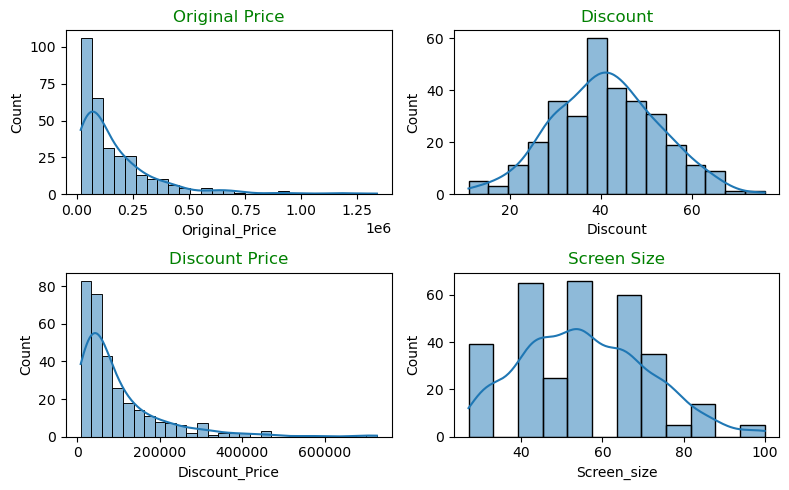

In [179]:
plt.figure(figsize=(8,5))

plt.subplot(2,2,1)
plt.title("Original Price",color="green")
sns.histplot(num["Original_Price"],kde=True)

plt.subplot(2,2,2)
plt.title("Discount",color="green")
sns.histplot(num["Discount"],kde=True)

plt.subplot(2,2,3)
plt.title("Discount Price",color="green")
sns.histplot(num["Discount_Price"],kde=True)


plt.subplot(2,2,4)
plt.title("Screen Size",color="green")
sns.histplot(num["Screen_size"],kde=True)

plt.tight_layout()
plt.show()

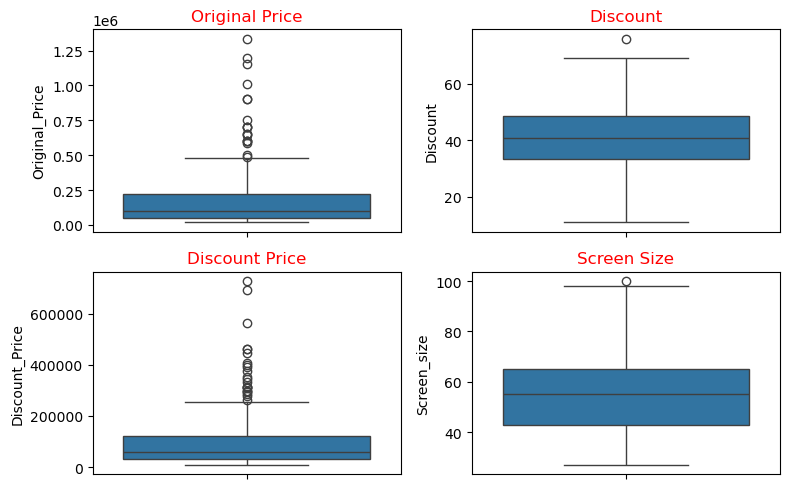

In [180]:
plt.figure(figsize=(8,5))

plt.subplot(2,2,1)
plt.title("Original Price",color="red")
sns.boxplot(num["Original_Price"])

plt.subplot(2,2,2)
plt.title("Discount",color="red")
sns.boxplot(num["Discount"])

plt.subplot(2,2,3)
plt.title("Discount Price",color="red")
sns.boxplot(num["Discount_Price"])

plt.subplot(2,2,4)
plt.title("Screen Size",color="red")
sns.boxplot(num["Screen_size"])

plt.tight_layout()
plt.show()

In [181]:
for col in df.select_dtypes(include=[int, float]):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    ub = q3 + 1.5 * iqr
    lb = q1 - 1.5 * iqr

    outliers = df[(df[col] > ub) | (df[col] < lb)]
    
    print(f"{col} - Number of outliers: {outliers.shape[0]}")
    print(outliers)

Original_Price - Number of outliers: 19
       Brand           Model  Original_Price  Discount  Discount_Price  \
17   Samsung             Q8F          645200        31          444900   
18   Samsung             Q8F         1152200        51          562900   
21   Samsung             Q8F         1013900        28          726900   
30   Samsung             Q8F         1336600        65          461900   
35   Samsung             Q8F          484900        28          350990   
116    Haier           HA32S          899990        66          309990   
139  Samsung        65S800QT          649900        47          343900   
142  Samsung        65S800QT          749900        38          462990   
160  Samsung  LS32DM500EWXXL         1199900        42          692590   
176  Samsung  LS32DM500EWXXL          699900        55          312900   
236       LG            UQ73          599990        45          332600   
245       LG           S25M2          899990        56          398700  

## Categorical

In [182]:
categorical= df.select_dtypes(include=["string"])
categorical

,Brand,Model,Resolution,Display
0,Xiaomi,Q8F,4K,LED
1,Xiaomi,Q8F,Full HD,LED
2,Xiaomi,Q8F,4K,QLED
3,Xiaomi,Q8F,4K,QLED
4,Xiaomi,Q8F,4K,QLED
...,...,...,...,...
350,Sony,Bose,4K,OLED
351,LG,Bose,4K,LED
352,LG,Bose,4K,LED
353,LG,Bose,4K,LED


In [183]:
len(categorical["Brand"].value_counts()),len(categorical["Display"].value_counts()),len(categorical["Model"].value_counts()),len(categorical["Resolution"].value_counts())

(11, 4, 8, 4)

In [184]:
len(categorical["Resolution"].value_counts())

4

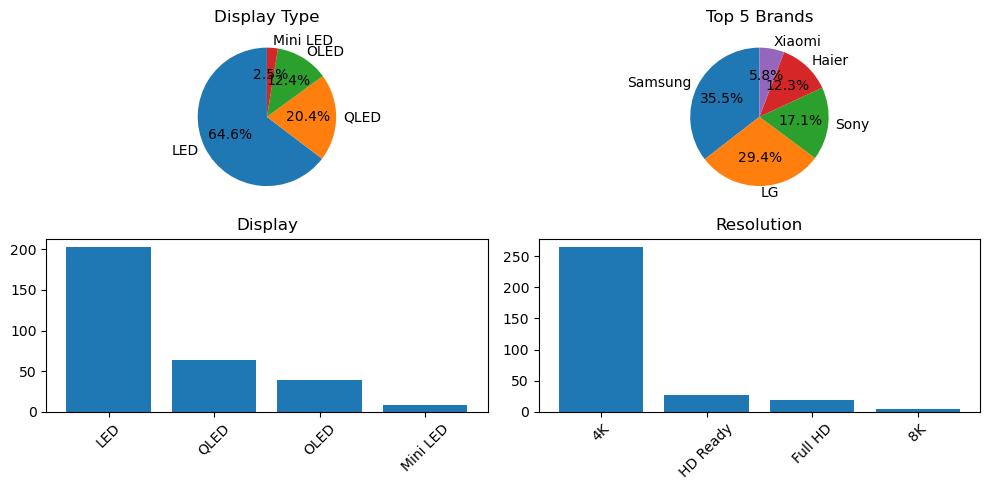

In [185]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,5))

# 1️) Display Pie
plt.subplot(2,2,1)
display_counts = categorical["Display"].value_counts()
plt.pie(display_counts, labels=display_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Display Type")

# 2️) Brand Pie
plt.subplot(2,2,2)
brand_counts = categorical["Brand"].value_counts().head(5)
plt.pie(brand_counts, labels=brand_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Top 5 Brands")

# 3️) Screen Size Bar
plt.subplot(2,2,3)
size_counts = categorical["Display"].value_counts()
plt.bar(size_counts.index, size_counts.values)
plt.xticks(rotation=45)
plt.title("Display")

# 4️) Resolution Bar
plt.subplot(2,2,4)
res_counts = categorical["Resolution"].value_counts()
plt.bar(res_counts.index, res_counts.values)
plt.xticks(rotation=45)
plt.title("Resolution")

plt.tight_layout()
plt.show()

# Bivariate Analysis

### 1)Screen Size vs Price

<Axes: xlabel='Screen_size', ylabel='Discount_Price'>

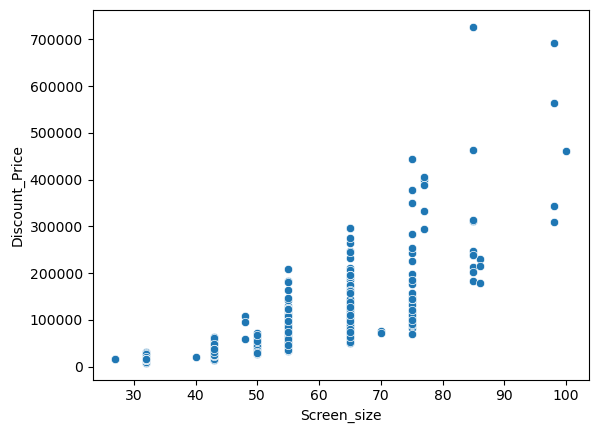

In [186]:
sns.scatterplot(data=df,x="Screen_size",y="Discount_Price")

### 2)Display vs Price

<Axes: xlabel='Display', ylabel='Discount_Price'>

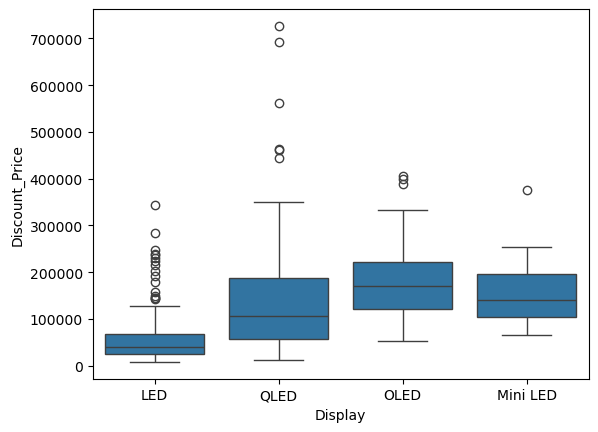

In [187]:
sns.boxplot(data=df,x="Display",y="Discount_Price")

### 3)Brand vs Price

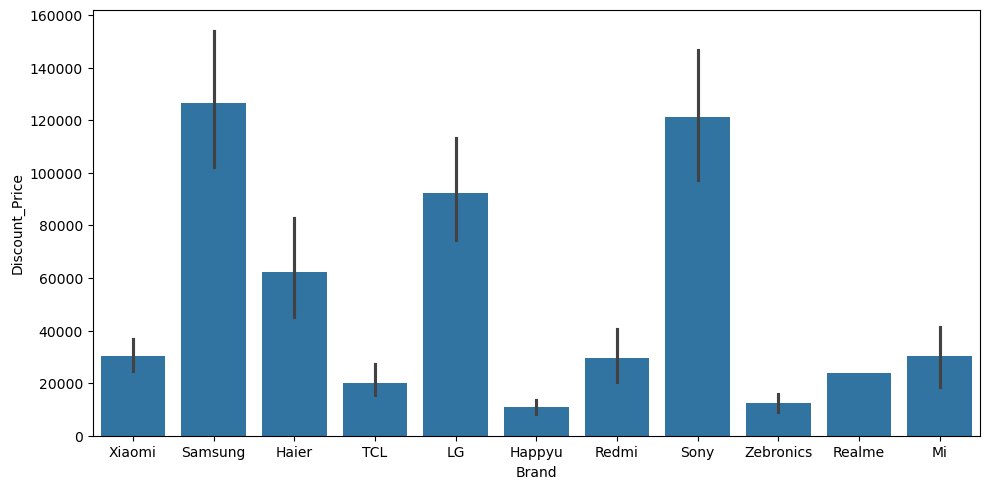

In [188]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="Brand",y="Discount_Price")
plt.tight_layout()

### 4) Display Type vs Price

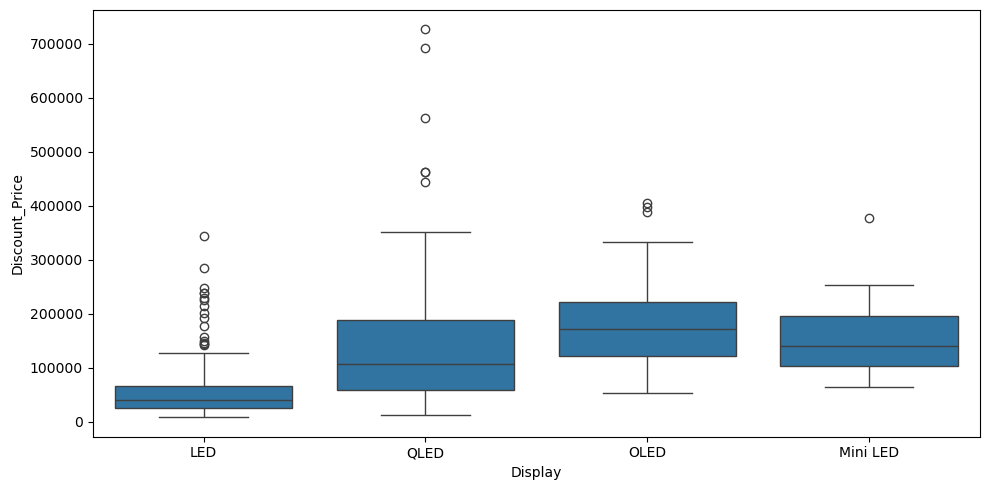

In [189]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x="Display",y="Discount_Price")
plt.tight_layout()

### 5)Resolution vs Price

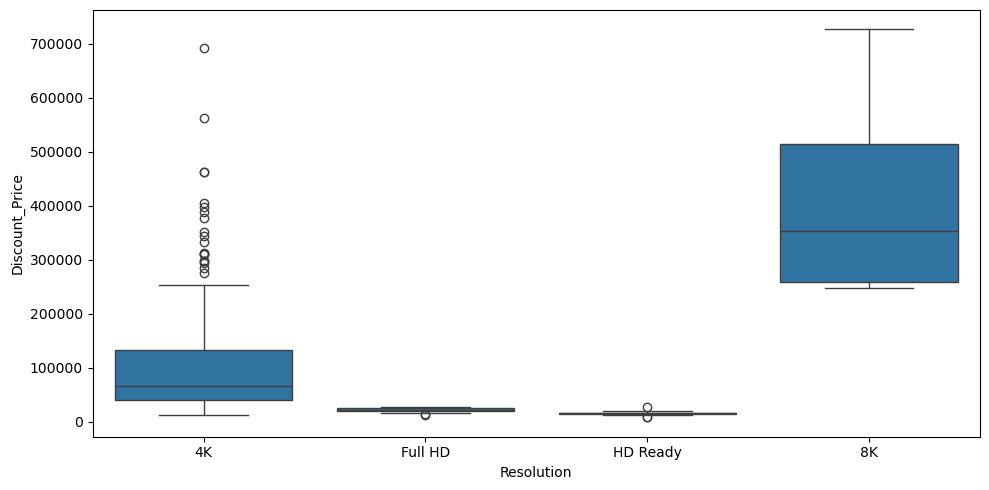

In [190]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x="Resolution",y="Discount_Price")
plt.tight_layout()

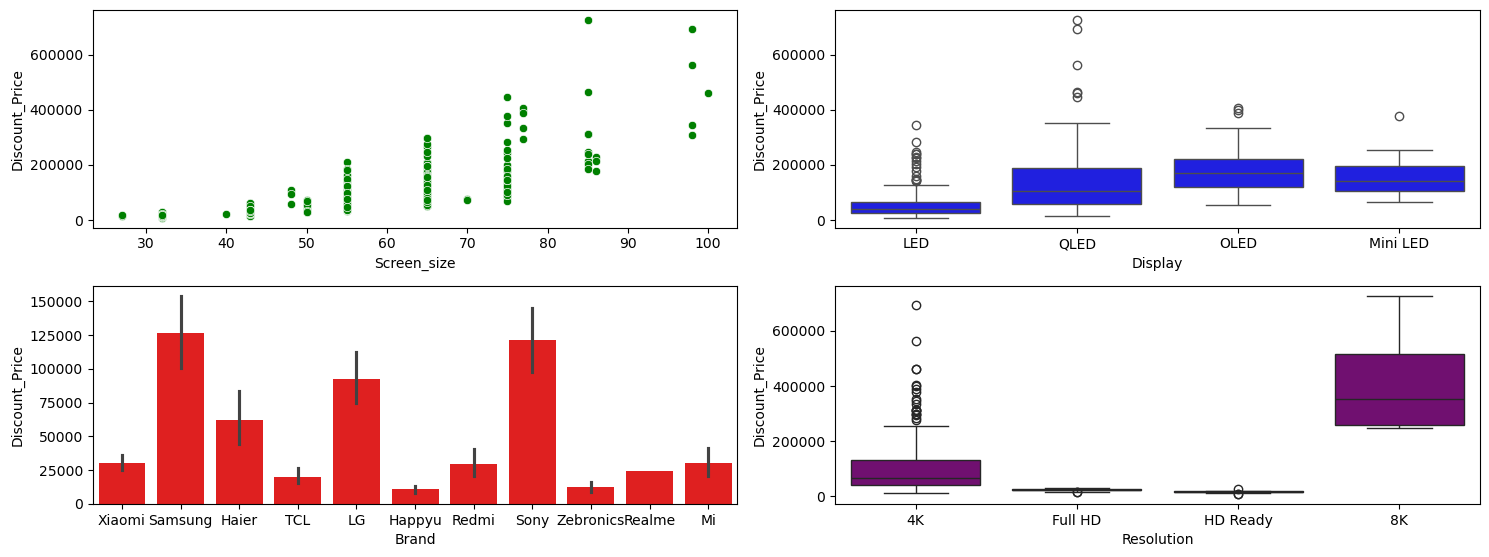

In [191]:
plt.figure(figsize=(15,8))
plt.subplot(3,2,1)
sns.scatterplot(data=df,x="Screen_size",y="Discount_Price",color="green")

plt.subplot(3,2,2)
sns.boxplot(data=df,x="Display",y="Discount_Price",color="blue")

plt.subplot(3,2,3)
sns.barplot(data=df,x="Brand",y="Discount_Price",color="red")

plt.subplot(3,2,4)
sns.boxplot(data=df,x="Resolution",y="Discount_Price",color="purple")

plt.tight_layout()

## 6) Original price versus discount

<Axes: xlabel='Original_Price', ylabel='Discount'>

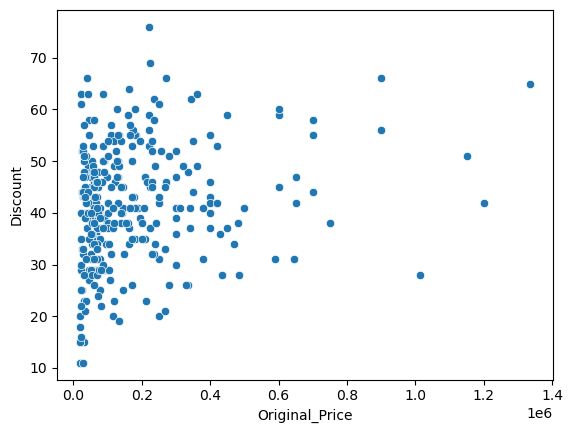

In [192]:
sns.scatterplot(data=df,x="Original_Price",y="Discount")

## 7) Brand vs Discount

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Xiaomi'),
  Text(1, 0, 'Samsung'),
  Text(2, 0, 'Haier'),
  Text(3, 0, 'TCL'),
  Text(4, 0, 'LG'),
  Text(5, 0, 'Happyu'),
  Text(6, 0, 'Redmi'),
  Text(7, 0, 'Sony'),
  Text(8, 0, 'Zebronics'),
  Text(9, 0, 'Realme'),
  Text(10, 0, 'Mi')])

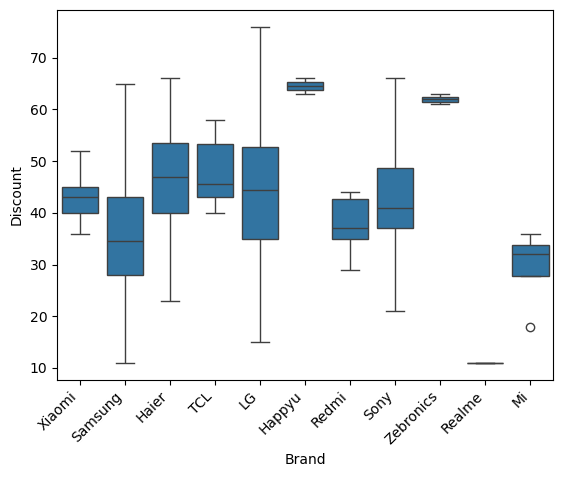

In [193]:
sns.boxplot(data=df,x="Brand",y="Discount")
plt.xticks(rotation=45, ha='right')

## Multivariate analysis

In [194]:
df

,Brand,Model,Original_Price,Discount,Discount_Price,Screen_size,Resolution,Display
0,Xiaomi,Q8F,24999,44,13999,32.0,4K,LED
1,Xiaomi,Q8F,34999,40,20999,43.0,Full HD,LED
2,Xiaomi,Q8F,99999,42,57999,65.0,4K,QLED
3,Xiaomi,Q8F,69999,43,39999,55.0,4K,QLED
4,Xiaomi,Q8F,49999,42,28999,43.0,4K,QLED
...,...,...,...,...,...,...,...,...
350,Sony,Bose,349900,44,196700,65.0,4K,OLED
351,LG,Bose,119990,38,74990,55.0,4K,LED
352,LG,Bose,169990,35,109990,65.0,4K,LED
353,LG,Bose,299990,52,144990,75.0,4K,LED


### Price vs Screen Size vs Resolution

<Axes: xlabel='Screen_size', ylabel='Discount_Price'>

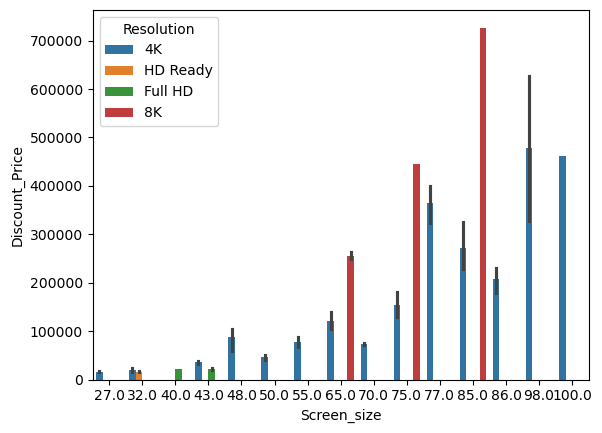

In [195]:
sns.barplot(data=df,hue="Resolution",x="Screen_size",y="Discount_Price")

## Discount_Price vs Display vs Brand

<Axes: xlabel='Display', ylabel='Discount_Price'>

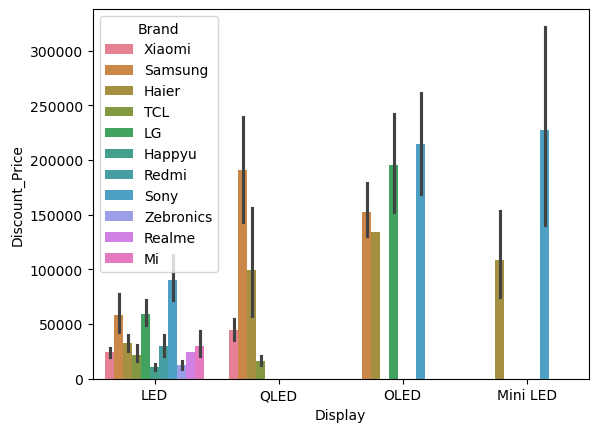

In [196]:
sns.barplot(data=df,hue="Brand",x="Display",y="Discount_Price")

## correlation between numerical columns

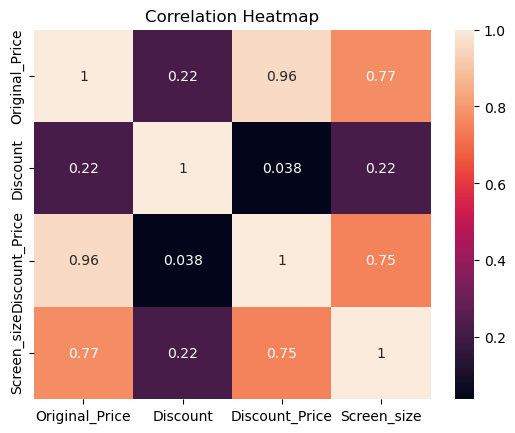

In [197]:
sns.heatmap(num.corr(), annot=True, cmap='rocket')
plt.title('Correlation Heatmap')
plt.show()


## WHY hypothesis comes AFTER visualization?

Visualization reveals patterns in the dataset.

Hypothesis testing verifies whether those patterns are statistically significant.

In [198]:
from scipy.stats import ttest_ind

sony = df[df['Brand'] == 'Sony']['Discount_Price']
samsung = df[df['Brand'] == 'LG']['Discount_Price']

t_stat, p_value = ttest_ind(sony, samsung)

print("T-statistic:", t_stat)
print("P-value:", p_value)
if p_value < 0.05:
    print("Reject Null Hypothesis, Ho: Brand affects TV price")
else:
    print("Fail to Reject Null Hypothesis, H1: Brand does not affect TV price")


T-statistic: 1.8160624817367785
P-value: 0.07159624621086375
Fail to Reject Null Hypothesis, H1: Brand does not affect TV price


In [199]:
small_tv = df[df['Screen_size'] < 50]['Discount_Price']
large_tv = df[df['Screen_size'] >= 50]['Discount_Price']

t_stat, p_value = ttest_ind(small_tv, large_tv)
print("P-value:", p_value)
if p_value < 0.05:
    print("Reject Null Hypothesis, Ho: Screen size affects TV price")
else:
    print("Fail to Reject Null Hypothesis, H1: Screen size does not affect TV price")

P-value: 6.05695596727092e-19
Reject Null Hypothesis, Ho: Screen size affects TV price


In [200]:
tv_4k = df[df['Resolution'] == '4K']['Discount_Price'].dropna()
tv_fhd = df[df['Resolution'] == 'Full HD']['Discount_Price'].dropna()

t_stat, p_value = ttest_ind(tv_4k, tv_fhd)

print("P-value:", p_value)
if p_value < 0.05:
    print("Reject Null Hypothesis, Ho: Resolution affects TV price")
else:
    print("Fail to Reject Null Hypothesis, H1: Resolution does not affect TV price")

P-value: 0.0004004880015628251
Reject Null Hypothesis, Ho: Resolution affects TV price


In [201]:
led = df[df['Display'] == 'LED']['Discount_Price'].dropna()
oled = df[df['Display'] == 'OLED']['Discount_Price'].dropna()

t_stat, p_value = ttest_ind(led, oled)

print("T-statistic:", t_stat)

print("P-value:", p_value)
if p_value < 0.05:
    print("Reject Null Hypothesis, Ho: Display type affects TV price")
else:
    print("Fail to Reject Null Hypothesis, H1: Display type does not affect TV price")

T-statistic: -12.36303523456291
P-value: 1.70782147994386e-27
Reject Null Hypothesis, Ho: Display type affects TV price


# ********************************************************Price Distribution Analysis********************************************************************

Price is right-skewed:- Most TVs are clustered in the ₹20k–₹45k range.

Extreme Outliers:- A few premium models (OLED/8K) reach ₹2L–₹5L+, which significantly pulls the mean upward.

Gap Analysis:- Large price jumps exist between standard LED and QLED/OLED display technologies.

*Interpretation*

Most customers (like Ananya) are shopping in the budget to mid-range segment.

The "Average Price" is a misleading metric for a typical buyer because of the "Luxury Tax" on high-end models.

-> Business Insight for Ananya

Follow the Median: Ananya should look at the median price for 55-inch TVs rather than the average, as the average is inflated by "Status Symbol" TVs that don't necessarily offer 2x the utility.

-> Display Technology & Resolution Analysis
What I did

Bar charts of Resolution (HD vs. 4K vs. 8K).

Boxplots of Price vs. Display Type (LED, QLED, OLED).

**What I observed**

4K is the Standard:- The majority of 50+ inch TVs are 4K.

Display Type = Price Driver:- OLED prices are significantly higher and show less price variance than LEDs.

8K Premium:- 8K TVs show an exponential price increase compared to 4K.

*Interpretation*

Resolution alone doesn't drive the ₹30k gap; the Panel Type (LED vs QLED) is the silent price inflator.

Moving from 4K to 8K offers diminishing returns for the average viewer.

-> Business Insight for Ananya

Hardware Over Jargon: If the ₹65,000 TV is an OLED and the ₹35,000 is an LED, the price is for Picture Quality. If both are LEDs, she is likely paying a "Logo Tax."

-> Screen Size Analysis
What I observed

Most TVs cluster around 32, 43, and 55 inches.

Price-per-Inch Plateau: The price increases linearly until 55 inches, then jumps sharply for 65+ inches.

*Interpretation*

55-inch is the current "Market Sweet Spot" where manufacturing efficiency meets consumer demand.

Beyond 65 inches, you pay a "Size Premium" that isn't proportional to the actual glass cost.

-> Business Insight for Ananya

The 55" Value:- Since she is looking at 55-inch models, she is in the most competitive segment. She has the most power to negotiate or find "Value Brands" here.

-> Discount & Original Price Analysis

Deep Discounts on Budget Brands:- Brands like Xiaomi/TCL show 30–50% discounts.

Price Protection on Premium Brands:- Sony/Samsung rarely show discounts above 10–15%.

*Interpretation*

Budget brands use "Anchor Pricing" (high original price) to create a psychological sense of a Deal.Premium brands maintain high prices to preserve 

Brand Prestige.

-> Business Insight for Ananya

Don't be Fooled by %:- A 44% discount on a budget TV might just bring it to its actual market value. She should compare the Final Price, not the Discount Percentage.

-> Bivariate & Multivariate EDA – Key Learnings
Price vs. Resolution/Size Visual Insight

Clear upward trend:- Larger size + Higher resolution = Higher Price.

However, the trend line breaks at the "Premium Tier", where prices skyrocket regardless of size increase.

**Correlation Heatmap**

Strong Correlation:- Price <-> Display Type, Price <-> Screen Size.

Weak Correlation:- Price <-> Brand (surprisingly, some budget brands have expensive large models too).

**Hypothesis Testing**

hypothesis testing was used to verify whether those patterns were statistically significant.

The analysis showed that screen size, resolution, and display type significantly influence TV prices. Larger screen sizes, higher resolutions like 4K, and advanced display technologies such as OLED generally lead to higher prices. However, the results indicated that brand alone does not have a significant impact on price in the analyzed dataset.

**Interpretation**

Technical hardware (Panel & Size) determines the baseline price.

Marketing and Brand positioning determine the "Top-up" price.

-> Final Decision Insight for Ananya

**Calculate Price-per-Inch**:- If the ₹65,000 TV doesn't offer a better Panel Technology (like QLED) over the ₹35,000 model, she should choose the cheaper one. The "Logo" does not improve the pixels.